In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("episodes.xlsx")

In [12]:
df.head()

,Season,No. overall,No. in season,Title,Director,Written by,Original air date,U.S. viewers (millions)
0,1,1,1,Winter Is Coming,Tim Van Patten,David Benioff & D. B. Weiss,2011-04-17,2.22
1,1,2,2,The Kingsroad,Tim Van Patten,David Benioff & D. B. Weiss,2011-04-24,2.20
2,1,3,3,Lord Snow,Brian Kirk,David Benioff & D. B. Weiss,2011-05-01,2.44
3,1,4,4,"Cripples, Bastards, and Broken Things",Brian Kirk,Bryan Cogman,2011-05-08,2.45
4,1,5,5,The Wolf and the Lion,Brian Kirk,David Benioff & D. B. Weiss,2011-05-15,2.58


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Season                   67 non-null     int64         
 1   No. overall              67 non-null     int64         
 2   No. in season            67 non-null     int64         
 3   Title                    67 non-null     str           
 4   Director                 67 non-null     str           
 5   Written by               67 non-null     str           
 6   Original air date        67 non-null     datetime64[us]
 7   U.S. viewers (millions)  67 non-null     float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(3)
memory usage: 4.3 KB


In [14]:
df.describe()

,Season,No. overall,No. in season,Original air date,U.S. viewers (millions)
count,67.000000,67.000000,67.000000,67,67.000000
mean,3.865672,34.000000,5.343284,2014-04-02 03:13:25.970149,5.951194
min,1.000000,1.000000,1.000000,2011-04-17 00:00:00,2.200000
25%,2.000000,17.500000,3.000000,2012-05-16 12:00:00,3.870000
50%,4.000000,34.000000,5.000000,2014-04-27 00:00:00,6.400000
75%,5.500000,50.500000,8.000000,2015-11-18 12:00:00,7.285000
max,7.000000,67.000000,10.000000,2017-08-27 00:00:00,12.070000
std,1.953207,19.485037,2.852709,NaN,2.363501


In [16]:
df.columns

Index(['Season', 'No. overall', 'No. in season', 'Title', 'Director',
       'Written by', 'Original air date', 'U.S. viewers (millions)'],
      dtype='str')

In [17]:
df.columns = [
    "season",
    "overall_episode",
    "season_episode",
    "title",
    "director",
    "writer",
    "air_date",
    "viewers_million"
]

In [18]:
df["air_date"] = pd.to_datetime(df["air_date"])

In [19]:
df["air_date"] = pd.to_datetime(df["air_date"])

In [20]:
df.isnull().sum()

season             0
overall_episode    0
season_episode     0
title              0
director           0
writer             0
air_date           0
viewers_million    0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.shape[0]

67

In [23]:
df["viewers_million"].mean()

np.float64(5.951194029850747)

In [24]:
df.loc[df["viewers_million"].idxmin()]

season                                       1
overall_episode                              2
season_episode                               2
title                            The Kingsroad
director                        Tim Van Patten
writer             David Benioff & D. B. Weiss
air_date                   2011-04-24 00:00:00
viewers_million                            2.2
Name: 1, dtype: object

In [25]:
season_avg = df.groupby("season")["viewers_million"].mean()

season_avg

season
1     2.515000
2     3.795000
3     4.966000
4     6.846000
5     6.880000
6     7.688000
7    10.261429
Name: viewers_million, dtype: float64

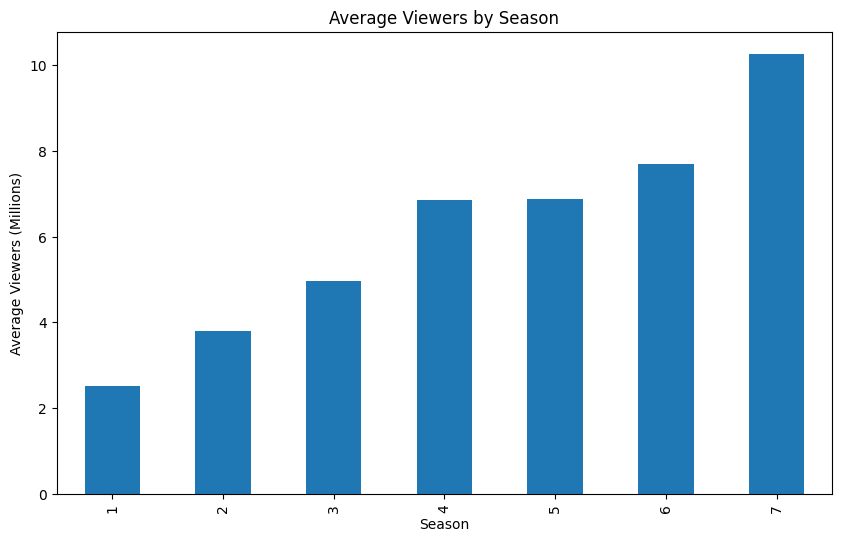

In [30]:
plt.figure(figsize=(10,6))

season_avg.plot(kind="bar")

plt.title("Average Viewers by Season")
plt.xlabel("Season")
plt.ylabel("Average Viewers (Millions)")

plt.show()

In [34]:
plt.savefig("viewers_by_season.png")

<Figure size 640x480 with 0 Axes>

In [41]:
top_episodes = df.sort_values(by= "U.S. viewers (millions)", ascending=False).head(10)

top_episodes

,Season,No. overall,No. in season,Title,Director,Written by,Original air date,U.S. viewers (millions)
66,7,67,7,The Dragon and the Wolf,Jeremy Podeswa,David Benioff & D. B. Weiss,2017-08-27,12.07
64,7,65,5,Eastwatch,Matt Shakman,Dave Hill,2017-08-13,10.72
65,7,66,6,Beyond the Wall,Alan Taylor,David Benioff & D. B. Weiss,2017-08-20,10.24
63,7,64,4,The Spoils of War,Matt Shakman,David Benioff & D. B. Weiss,2017-08-06,10.17
60,7,61,1,Dragonstone,Jeremy Podeswa,David Benioff & D. B. Weiss,2017-07-16,10.11
61,7,62,2,Stormborn,Mark Mylod,Bryan Cogman,2017-07-23,9.27
62,7,63,3,The Queen's Justice,Mark Mylod,David Benioff & D. B. Weiss,2017-07-30,9.25
59,6,60,10,The Winds of Winter,Miguel Sapochnik,David Benioff & D. B. Weiss,2016-06-26,8.89
49,5,50,10,Mother's Mercy,David Nutter,David Benioff & D. B. Weiss,2015-06-14,8.11
40,5,41,1,The Wars to Come,Michael Slovis,David Benioff & D. B. Weiss,2015-04-12,8.00


In [48]:
df.columns = [
    "season",
    "overall_episode",
    "season_episode",
    "title",
    "director",
    "writer",
    "air_date",
    "viewers_million"
]

In [49]:
top_episodes = df.sort_values(
    by="viewers_million",
    ascending=False
).head(10)

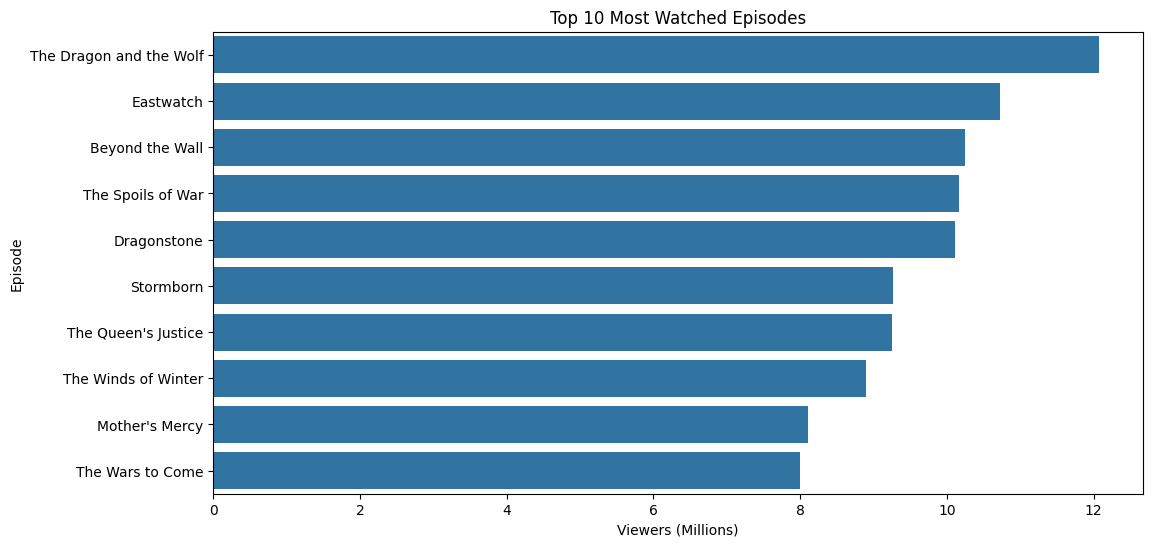

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_episodes,
    x="viewers_million",
    y="title"
)

plt.title("Top 10 Most Watched Episodes")
plt.xlabel("Viewers (Millions)")
plt.ylabel("Episode")

plt.show()

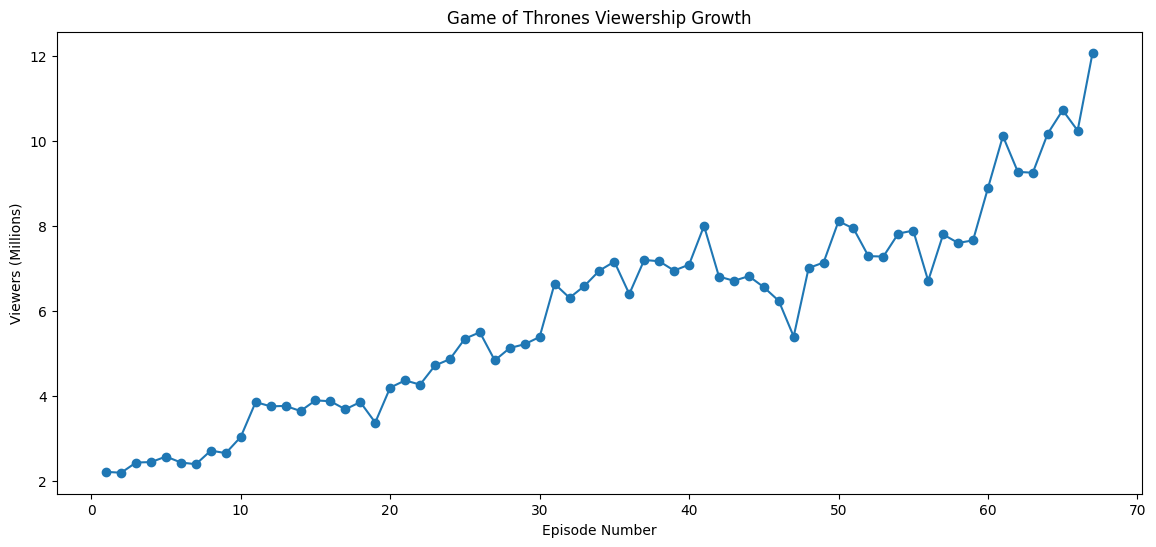

In [51]:
plt.figure(figsize=(14,6))

plt.plot(
    df["overall_episode"],
    df["viewers_million"],
    marker='o'
)

plt.title("Game of Thrones Viewership Growth")
plt.xlabel("Episode Number")
plt.ylabel("Viewers (Millions)")

plt.show()

In [52]:
director_count = df["director"].value_counts()

director_count

director
Alan Taylor          7
David Nutter         6
Alex Graves          6
Mark Mylod           6
Jeremy Podeswa       6
Daniel Minahan       5
Alik Sakharov        4
Michelle MacLaren    4
Miguel Sapochnik     4
Brian Kirk           3
Tim Van Patten       2
David Petrarca       2
Neil Marshall        2
Michael Slovis       2
Daniel Sackheim      2
Jack Bender          2
Matt Shakman         2
David Benioff        1
D. B. Weiss          1
Name: count, dtype: int64

In [53]:
director_count = df["director"].value_counts()

director_count

director
Alan Taylor          7
David Nutter         6
Alex Graves          6
Mark Mylod           6
Jeremy Podeswa       6
Daniel Minahan       5
Alik Sakharov        4
Michelle MacLaren    4
Miguel Sapochnik     4
Brian Kirk           3
Tim Van Patten       2
David Petrarca       2
Neil Marshall        2
Michael Slovis       2
Daniel Sackheim      2
Jack Bender          2
Matt Shakman         2
David Benioff        1
D. B. Weiss          1
Name: count, dtype: int64

In [54]:
director_avg = df.groupby("director")["viewers_million"].mean().sort_values(ascending=False)

director_avg

director
Matt Shakman         10.445000
Jeremy Podeswa        8.368333
Mark Mylod            7.908333
Daniel Sackheim       7.550000
Michael Slovis        7.405000
Jack Bender           7.300000
Miguel Sapochnik      7.240000
D. B. Weiss           6.640000
Alex Graves           6.230000
Michelle MacLaren     6.020000
Alik Sakharov         5.717500
David Nutter          5.571667
Neil Marshall         5.165000
David Benioff         4.720000
Alan Taylor           4.517143
David Petrarca        3.775000
Daniel Minahan        3.240000
Brian Kirk            2.490000
Tim Van Patten        2.210000
Name: viewers_million, dtype: float64

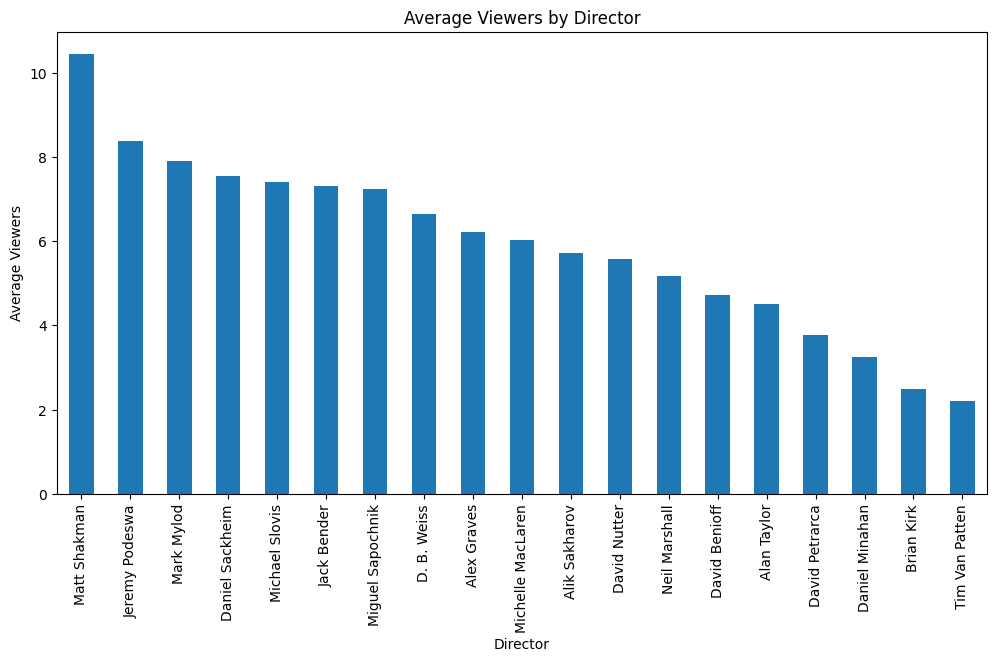

In [55]:
plt.figure(figsize=(12,6))

director_avg.plot(kind="bar")

plt.title("Average Viewers by Director")
plt.xlabel("Director")
plt.ylabel("Average Viewers")

plt.show()

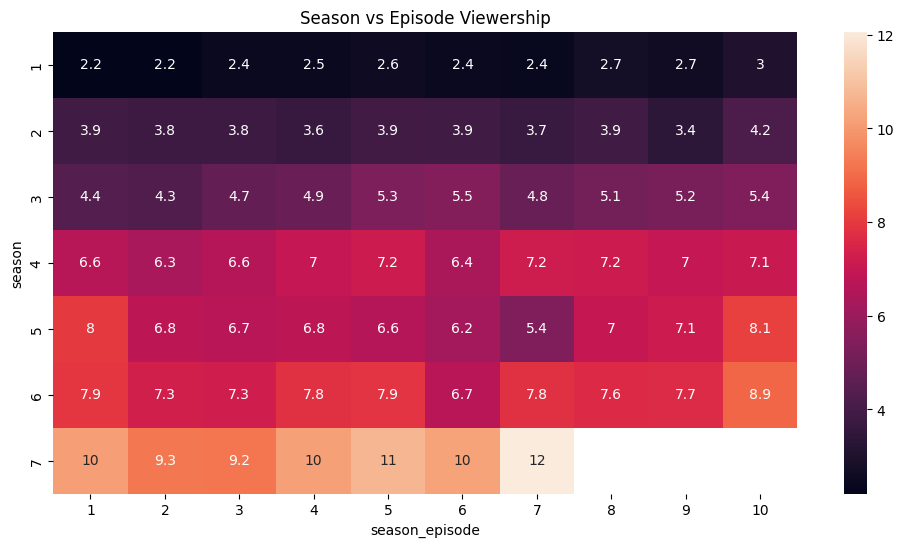

In [ ]:
pivot = df.pivot_table(
    values="viewers_million",
    index="season",
    columns="season_episode"
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot, annot=True)

plt.title("Season vs Episode Viewership")

plt.show()

"""Season 7 has highest audience"""

In [62]:
correlation = df[[
    "season",
    "overall_episode",
    "viewers_million"
]].corr()

correlation

,season,overall_episode,viewers_million
season,1.000000,0.989311,0.953782
overall_episode,0.989311,1.000000,0.953090
viewers_million,0.953782,0.953090,1.000000


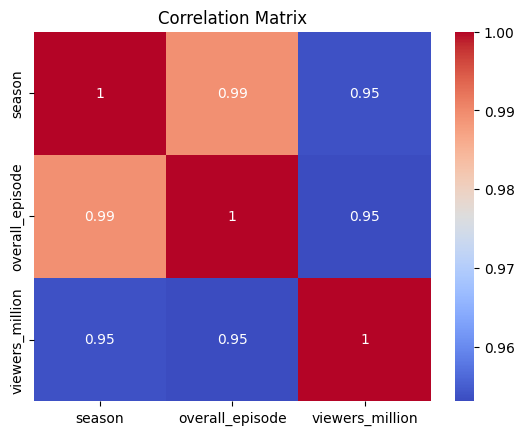

In [ ]:
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [60]:
df.to_csv("got_cleaned.csv", index=False)